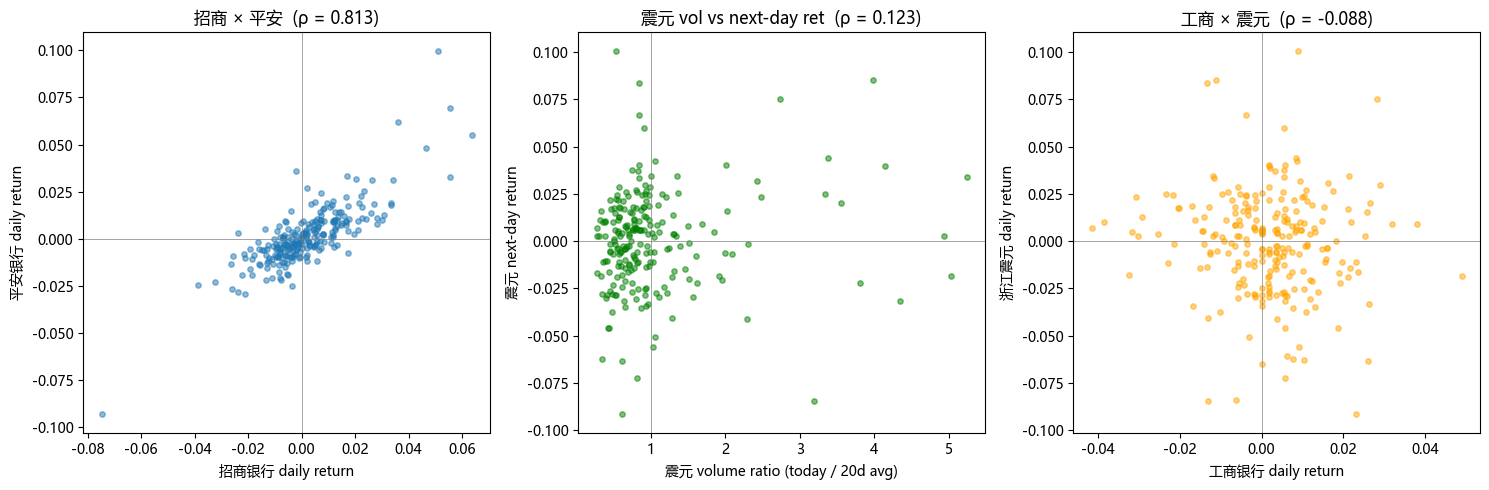

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils import load_or_fetch
from plot_setup import setup_chinese_font
setup_chinese_font()

codes = {
    '招商': 'sh.600036',
    '平安': 'sz.000001',
    '工商': 'sh.601398',
    '茅台': 'sh.600519',
    '汾酒': 'sh.600809',
    '震元': 'sz.000705',
}
data = {name: load_or_fetch(code, '2024-01-01', '2024-12-31') for name, code in codes.items()}

# Returns panel
returns = pd.DataFrame({
    name: df['close'].pct_change()
    for name, df in data.items()
}).dropna()

# Volume signal on 震元
zy = data['震元'].copy()
zy['vol_ratio'] = zy['volume'] / zy['volume'].rolling(20).mean()
zy['next_ret'] = zy['close'].pct_change().shift(-1)
vol_df = zy[['vol_ratio', 'next_ret']].dropna()

# Three-panel figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Pair 1: 招商 × 平安
x1, y1 = returns['招商'], returns['平安']
axes[0].scatter(x1, y1, alpha=0.5, s=15)
axes[0].set(xlabel='招商银行 daily return', ylabel='平安银行 daily return',
            title=f'招商 × 平安  (ρ = {x1.corr(y1):.3f})')
axes[0].axhline(0, color='gray', lw=0.5); axes[0].axvline(0, color='gray', lw=0.5)

# Pair 2: 震元 volume ratio × next-day return
x2, y2 = vol_df['vol_ratio'], vol_df['next_ret']
axes[1].scatter(x2, y2, alpha=0.5, s=15, color='green')
axes[1].set(xlabel='震元 volume ratio (today / 20d avg)',
            ylabel='震元 next-day return',
            title=f'震元 vol vs next-day ret  (ρ = {x2.corr(y2):.3f})')
axes[1].axhline(0, color='gray', lw=0.5); axes[1].axvline(1, color='gray', lw=0.5)

# Pair 3: 工商 × 震元
x3, y3 = returns['工商'], returns['震元']
axes[2].scatter(x3, y3, alpha=0.5, s=15, color='orange')
axes[2].set(xlabel='工商银行 daily return', ylabel='浙江震元 daily return',
            title=f'工商 × 震元  (ρ = {x3.corr(y3):.3f})')
axes[2].axhline(0, color='gray', lw=0.5); axes[2].axvline(0, color='gray', lw=0.5)

plt.tight_layout()
plt.show()

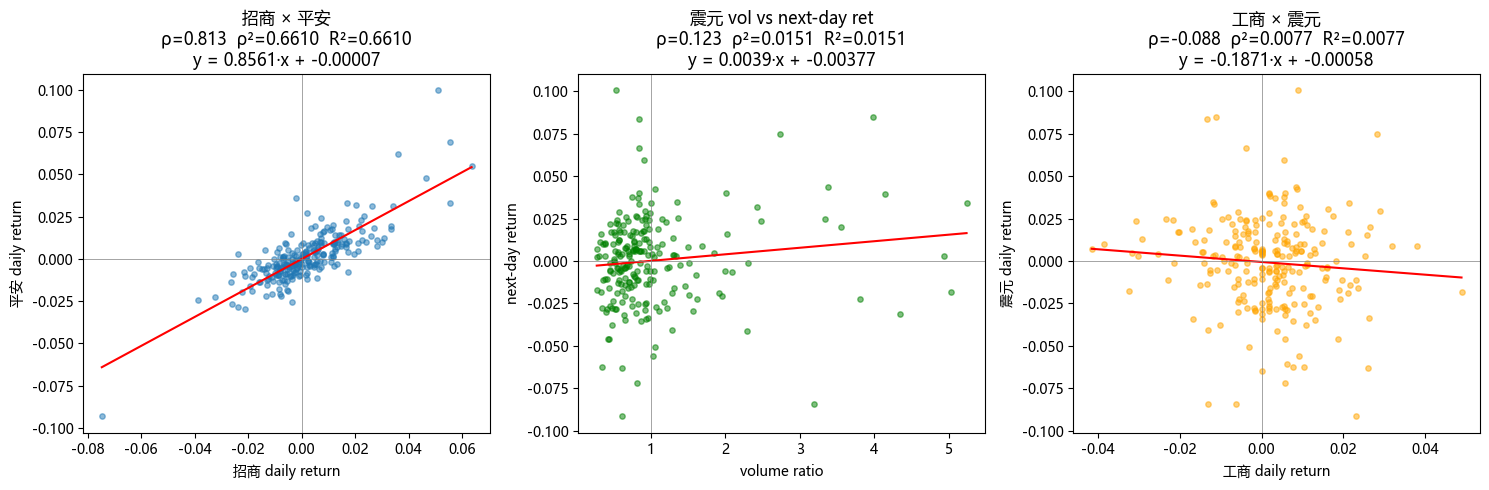

Pair                        ρ         ρ²         R²      slope    intercept
招商×平安                  0.8130     0.6610     0.6610     0.8561     -0.00007
震元 vol signal          0.1229     0.0151     0.0151     0.0039     -0.00377
工商×震元                 -0.0877     0.0077     0.0077    -0.1871     -0.00058


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def plot_with_regression(ax, x, y, title_prefix, xlabel, ylabel, color='C0', x_ref=0):
    mask = x.notna() & y.notna()
    x, y = x[mask], y[mask]
    
    # Fit line via ordinary least squares (degree-1 polyfit)
    slope, intercept = np.polyfit(x, y, 1)
    
    # R² from the definition
    y_pred = slope * x + intercept
    ss_res = ((y - y_pred) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    
    # ρ² for identity check
    rho = x.corr(y)
    rho_sq = rho ** 2
    
    ax.scatter(x, y, alpha=0.5, s=15, color=color)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, 'r-', lw=1.5)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(x_ref, color='gray', lw=0.5)
    ax.set_title(f'{title_prefix}\nρ={rho:.3f}  ρ²={rho_sq:.4f}  R²={r2:.4f}\ny = {slope:.4f}·x + {intercept:.5f}')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    
    return {'slope': slope, 'intercept': intercept, 'rho': rho, 'r2': r2, 'rho_sq': rho_sq}

results = {}
results['招商×平安'] = plot_with_regression(
    axes[0], returns['招商'], returns['平安'],
    '招商 × 平安', '招商 daily return', '平安 daily return', 'C0', 0)
results['震元 vol signal'] = plot_with_regression(
    axes[1], vol_df['vol_ratio'], vol_df['next_ret'],
    '震元 vol vs next-day ret', 'volume ratio', 'next-day return', 'green', 1)
results['工商×震元'] = plot_with_regression(
    axes[2], returns['工商'], returns['震元'],
    '工商 × 震元', '工商 daily return', '震元 daily return', 'orange', 0)

plt.tight_layout(); plt.show()

print(f"{'Pair':<20} {'ρ':>8} {'ρ²':>10} {'R²':>10} {'slope':>10} {'intercept':>12}")
for name, r in results.items():
    print(f"{name:<20} {r['rho']:>8.4f} {r['rho_sq']:>10.4f} {r['r2']:>10.4f} {r['slope']:>10.4f} {r['intercept']:>12.5f}")

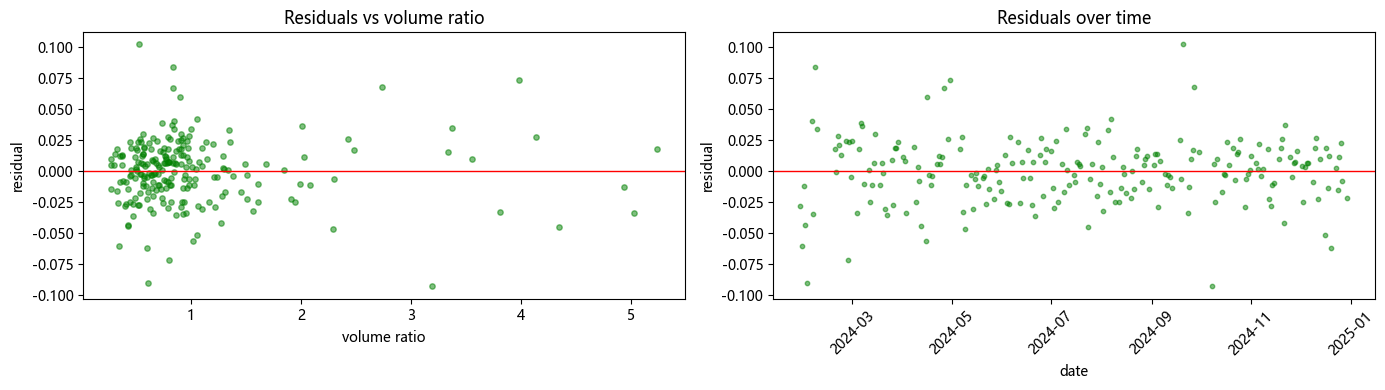

Residual mean:   0.000000   (≈ 0 by construction)
Residual std:    0.026018
y.std():         0.026217
std ratio:       0.9924   (should ≈ √(1−R²) = 0.9924)
Residual skew:   -0.0090   (vs y.skew() = 0.1166)
Residual kurt:   2.3036   (vs y.kurtosis() = 2.2487)


In [5]:
# Residuals for the 震元 volume signal
x = vol_df['vol_ratio']
y = vol_df['next_ret']
slope, intercept = np.polyfit(x, y, 1)
y_pred = slope * x + intercept
resid = y - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Residuals vs predictor
axes[0].scatter(x, resid, alpha=0.5, s=15, color='green')
axes[0].axhline(0, color='red', lw=1)
axes[0].set(xlabel='volume ratio', ylabel='residual',
            title='Residuals vs volume ratio')

# Residuals over time
axes[1].scatter(resid.index, resid, alpha=0.5, s=10, color='green')
axes[1].axhline(0, color='red', lw=1)
axes[1].set(xlabel='date', ylabel='residual',
            title='Residuals over time')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()

print(f"Residual mean:   {resid.mean():.6f}   (≈ 0 by construction)")
print(f"Residual std:    {resid.std():.6f}")
print(f"y.std():         {y.std():.6f}")
print(f"std ratio:       {resid.std() / y.std():.4f}   (should ≈ √(1−R²) = {np.sqrt(1 - 0.0151):.4f})")
print(f"Residual skew:   {resid.skew():.4f}   (vs y.skew() = {y.skew():.4f})")
print(f"Residual kurt:   {resid.kurtosis():.4f}   (vs y.kurtosis() = {y.kurtosis():.4f})")